# Анализ культурной инфраструктуры города Томска
## Оценка распределения, спектра услуг и выявление дефицита учреждений культуры

## 1. Цель и задачи исследования
**Цель** – оценить текущее состояние культурной инфраструктуры Томска на основе данных OpenStreetMap: распределение учреждений культуры по районам, разнообразие типов учреждений, выявление зон с недостатком услуг и формулирование рекомендаций.

**Задачи**:
- Загрузить и подготовить данные о границах районов Томска.
- Загрузить учреждения культуры по ключевым тегам (музеи, театры, библиотеки, кинотеатры, центры искусств, дома культуры).
- Проанализировать распределение по районам.
- Построить карты (хороплет и точечную) и диаграммы.
- Выявить недостающие типы учреждений.
- Сформулировать выводы и предложения по развитию культурной инфраструктуры на основе проведенного анализа.

## 2. Импорт библиотек и настройки

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx
import os
import time
import random
import mapclassify
import warnings
import urllib3

# Подавление предупреждений
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='urllib3')

# Настройки OSMnx для надёжности
ox.settings.timeout = 600
ox.settings.requests_kwargs = {'verify': False}
ox.settings.log_console = False
# Альтернативный endpoint
try:
    ox.settings.overpass_url = 'https://overpass.kumi.systems/api/interpreter'
    ox.settings.overpass_endpoint = 'https://overpass.kumi.systems/api/interpreter'
except AttributeError:
    pass

print("Библиотеки загружены, настройки применены.")

Библиотеки загружены, настройки применены.


## 3. Загрузка и подготовка границ районов Томска

In [2]:
# папки для данных
os.makedirs('data', exist_ok=True)
cached_districts = 'data/tomsk_districts.gpkg'

if not os.path.exists(cached_districts):
    print("Загружаем районы Томска...")
    city_gdf = ox.geocode_to_gdf('Томск, Россия')
    city_polygon = city_gdf.geometry.union_all()
    
    # admin_level=5, admin_level=8
    districts_raw = None
    for level in (5, 8):
        try:
            print(f"Пробуем admin_level={level}...")
            districts_raw = ox.features_from_polygon(
                city_polygon,
                tags={'boundary': 'administrative', 'admin_level': str(level)}
            )
            if not districts_raw.empty:
                break
        except Exception:
            continue
    
    if districts_raw is None or districts_raw.empty:
        print("Используем список районов...")
        names = [
            'Кировский район, Томск, Россия',
            'Ленинский район, Томск, Россия',
            'Октябрьский район, Томск, Россия',
            'Советский район, Томск, Россия'
        ]
        districts_list = []
        for name in names:
            try:
                d = ox.geocode_to_gdf(name)
                if not d.empty:
                    districts_list.append(d)
            except Exception:
                pass
        districts_raw = gpd.GeoDataFrame(pd.concat(districts_list, ignore_index=True))
    
    # фильтрация и перевод в UTM
    districts_raw = districts_raw[districts_raw.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()
    utm_crs = districts_raw.estimate_utm_crs()
    districts_utm = districts_raw.to_crs(utm_crs)
    districts_utm = districts_utm.drop_duplicates(subset='name')
    
    # сохраняем в кэш
    districts_utm.to_file(cached_districts, driver='GPKG')
    print(f"Районы сохранены в {cached_districts}")
else:
    print("Загружаем районы из кэша...")
    districts_utm = gpd.read_file(cached_districts)

print(f"Районов загружено: {len(districts_utm)}")
print("Список:", districts_utm['name'].tolist())

Загружаем районы из кэша...
Районов загружено: 4
Список: ['Кировский район', 'Ленинский район', 'Октябрьский район', 'Советский район']


## 4. Загрузка учреждений культуры

In [3]:
culture_cache = 'data/tomsk_culture_by_district.gpkg'

# объединяем все теги в один словарь для одного запроса
tags_combined = {
    'tourism': 'museum',
    'amenity': ['theatre', 'library', 'arts_centre', 'cinema', 'community_centre']
}

def load_culture_for_district(district_polygon, district_name, max_retries=3):
    """Загружает все объекты культуры для района одним запросом."""
    for attempt in range(max_retries):
        try:
            print(f"  Загружаем объекты для {district_name}...")
            gdf = ox.features_from_polygon(district_polygon, tags=tags_combined)
            if gdf.empty:
                return gdf
            gdf = gdf[gdf.geom_type.isin(['Point', 'Polygon', 'MultiPolygon'])].copy()
            print(f"    Загружено: {len(gdf)} объектов")
            return gdf
        except Exception as e:
            print(f"    Попытка {attempt+1} не удалась: {e}")
            if attempt < max_retries - 1:
                wait = 10 * (2 ** attempt) + random.uniform(0, 5)
                print(f"    Повтор через {wait:.0f} сек...")
                time.sleep(wait)
            else:
                return gpd.GeoDataFrame()

if not os.path.exists(culture_cache):
    print("Загружаем учреждения культуры по районам (один запрос на район)...")
    culture_list = []
    for idx, district in districts_utm.iterrows():
        district_name = district['name']
        polygon = district['geometry']
        print(f"Район: {district_name}")
        gdf = load_culture_for_district(polygon, district_name)
        if not gdf.empty:
            culture_list.append(gdf)
    if culture_list:
        culture = gpd.GeoDataFrame(pd.concat(culture_list, ignore_index=True))
        culture = culture.drop_duplicates(subset='geometry')
    else:
        culture = gpd.GeoDataFrame()
    culture.to_file(culture_cache, driver='GPKG')
    print(f"Объектов культуры сохранено: {len(culture)}")
else:
    print("Загружаем объекты культуры из кэша...")
    culture = gpd.read_file(culture_cache)
    print(f"Загружено из кэша: {len(culture)}")

if culture.empty:
    print("Нет данных о культуре. Завершение.")
else:
    print("Готово к анализу.")

Загружаем объекты культуры из кэша...
Загружено из кэша: 71
Готово к анализу.


## 5. Классификация учреждений по типам

In [4]:
# Определяем функцию для определения типа учреждения на основе тегов
def get_culture_type(row):
    if row.get('tourism') == 'museum':
        return 'Музей'
    elif row.get('amenity') == 'theatre':
        return 'Театр'
    elif row.get('amenity') == 'library':
        return 'Библиотека'
    elif row.get('amenity') == 'arts_centre':
        return 'Центр искусств'
    elif row.get('amenity') == 'cinema':
        return 'Кинотеатр'
    elif row.get('amenity') == 'community_centre':
        return 'Дом культуры'
    else:
        return 'Другое'

culture['type'] = culture.apply(get_culture_type, axis=1)

# Просмотр первых строк
print("Примеры учреждений культуры:")
display(culture[['name', 'type']].head(10))

Примеры учреждений культуры:


,name,type
0,Версия,Театр
1,Музей деревянного зодчества,Музей
2,Библиотека ТГПУ,Библиотека
3,Научная библиотека Томского государственного у...,Библиотека
4,Компьютерный мир,Библиотека
5,Центральная,Библиотека
6,Сказка,Библиотека
7,Минералогический музей,Музей
8,Музей томского пива,Музей
9,Степановская,Библиотека


## 6. Пространственный анализ: распределение по районам

In [14]:
# приводим объекты культуры к той же CRS, что и районы
culture_utm = culture.to_crs(districts_utm.crs)

# пространственное соединение: объекты внутри районов
culture_in_districts = gpd.sjoin(culture_utm, districts_utm, how='inner', predicate='within')

# подсчёт по типам
type_counts = culture_in_districts.groupby(['index_right', 'type']).size().reset_index(name='count')
type_pivot = type_counts.pivot(index='index_right', columns='type', values='count').fillna(0).astype(int)

# убедимся, что districts_utm содержит колонку name
if 'name' not in districts_utm.columns:
    if 'name:ru' in districts_utm.columns:
        districts_utm['name'] = districts_utm['name:ru']
    else:
        districts_utm['name'] = 'Неизвестно'

districts_with_types = districts_utm.merge(type_pivot, left_index=True, right_index=True, how='left')

# заполняем NaN
numeric_cols = list(type_pivot.columns)
for col in numeric_cols:
    districts_with_types[col] = districts_with_types[col].fillna(0).astype(int)

print(districts_with_types[['name'] + numeric_cols].head())

                name  Библиотека  Дом культуры  Кинотеатр  Музей  Театр  \
0    Кировский район           9             1          1      5      2   
1    Ленинский район           4             1          2      4      1   
2  Октябрьский район           4             2          1      3      2   
3    Советский район          11             4          1      5      2   

   Центр искусств  
0               1  
1               0  
2               3  
3               2  


## 7. Статистика по районам и типам учреждений

In [6]:
print("Общее количество учреждений культуры по районам:")
print(districts_with_culture[['name', 'culture_count']].sort_values('culture_count', ascending=False))

print("\nКоличество учреждений по типам в целом:")
print(culture['type'].value_counts())

Общее количество учреждений культуры по районам:
                name  culture_count
3    Советский район             25
0    Кировский район             19
2  Октябрьский район             15
1    Ленинский район             12

Количество учреждений по типам в целом:
type
Библиотека        28
Музей             17
Дом культуры       8
Театр              7
Центр искусств     6
Кинотеатр          5
Name: count, dtype: int64


## 8. Визуализация: хороплетная карта общего количества учреждений

Карта сохранена в ../output\culture_Tomsk_map.png


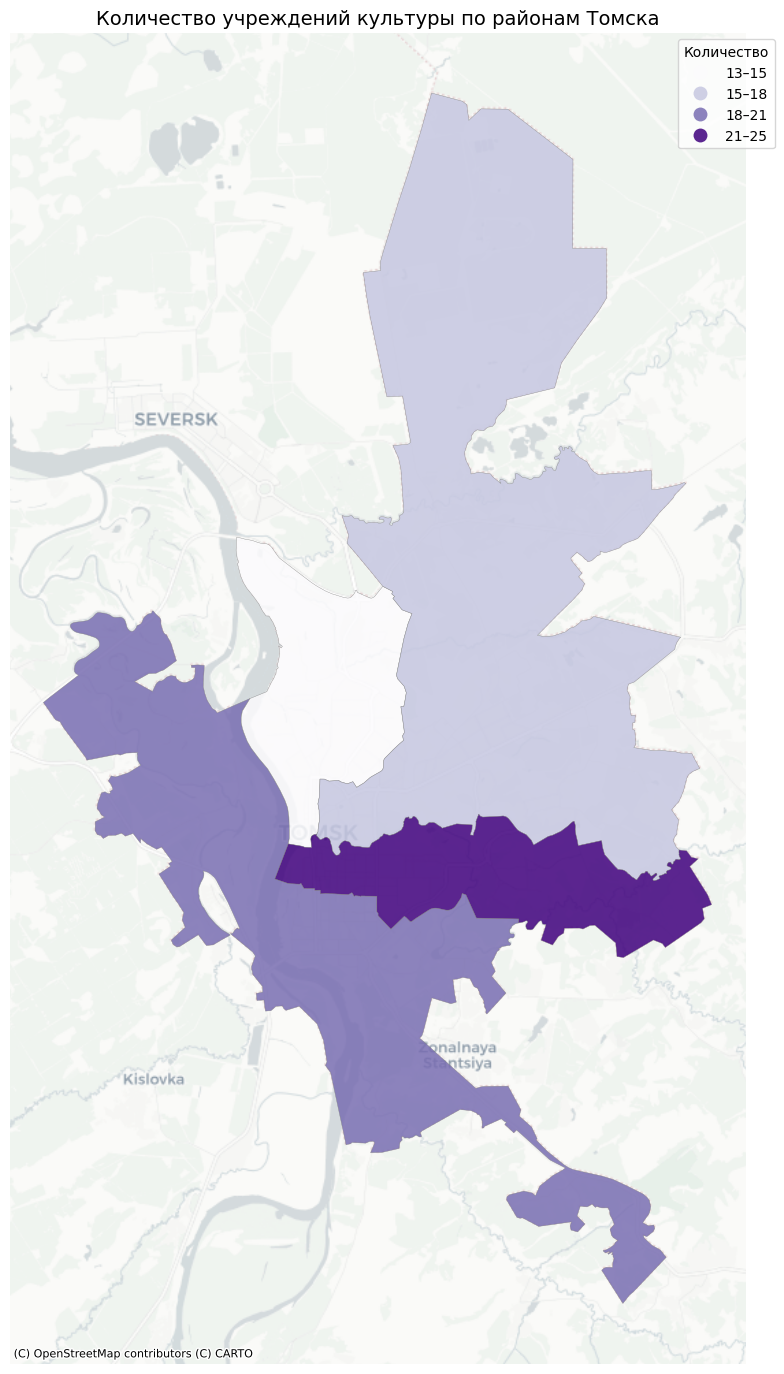

In [7]:
def plot_map(data, column, title, cmap='Purples'):
    data_wm = data.to_crs(epsg=3857)
    # классификация (квантили, 5 классов)
    q = mapclassify.Quantiles(data[column].dropna(), k=5)
    bins = q.bins
    n_classes = len(bins) - 1
    if n_classes <= 0:
        n_classes = 1
        labels = [f"{int(bins[0])}–{int(bins[-1])}"]
    else:
        labels = [f"{int(bins[i])}–{int(bins[i+1])}" for i in range(n_classes)]

    fig, ax = plt.subplots(figsize=(14, 14))
    data_wm.plot(
        column=column,
        cmap=cmap,
        scheme='Quantiles' if n_classes > 1 else None,
        k=n_classes if n_classes > 1 else None,
        legend=True,
        edgecolor='gray',
        linewidth=0.3,
        alpha=0.85,
        ax=ax,
        legend_kwds={
            'title': 'Количество',
            'bbox_to_anchor': (1.05, 1),
            'labels': labels if n_classes > 1 else None
        }
        
    )
    cx.add_basemap(ax, crs=data_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    
    # сохранение в файл
    output_dir = "../output"
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, 'culture_Tomsk_map.png')
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Карта сохранена в {filepath}")

    plt.tight_layout()
    plt.savefig(f'output/{column}.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_map(districts_with_culture, 'culture_count', 'Количество учреждений культуры по районам Томска')

## 9. Точечная карта учреждений культуры

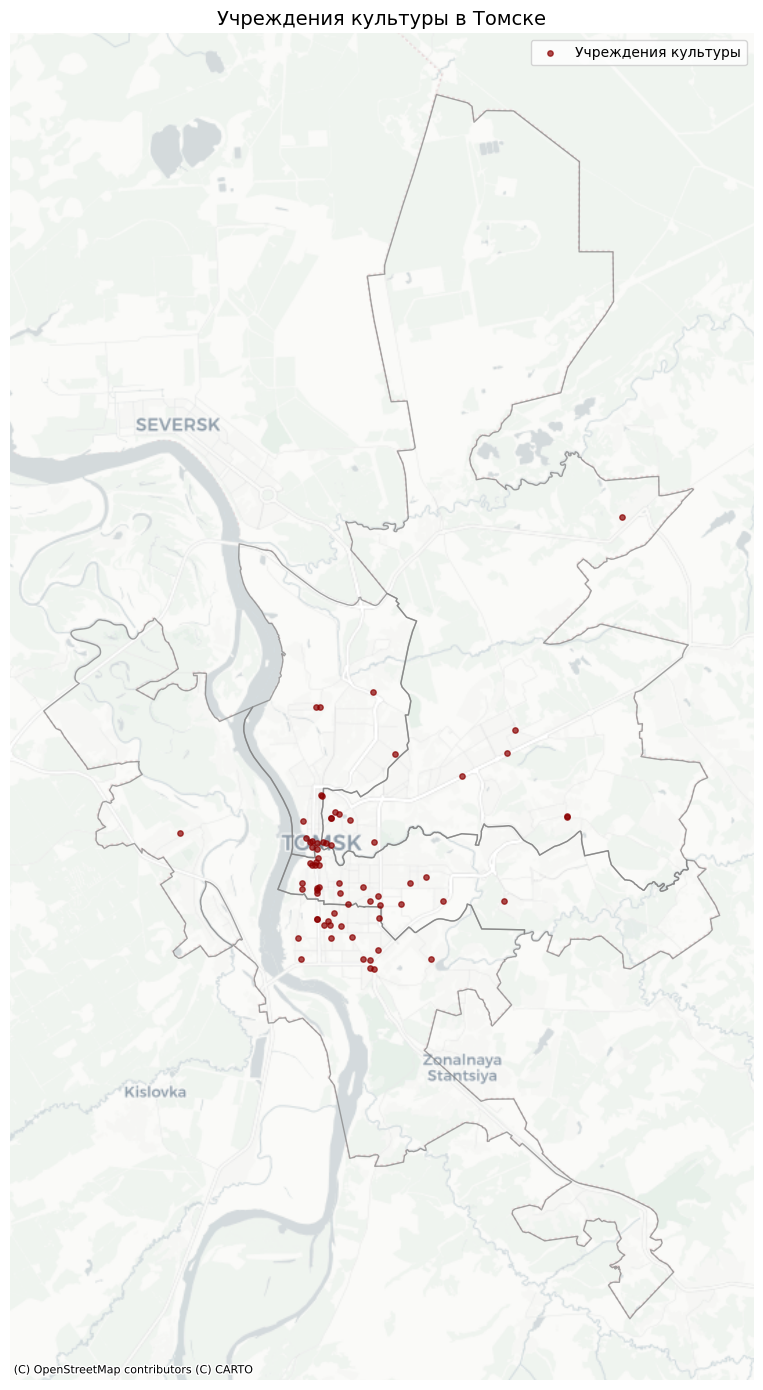

,name,amenity,tourism
0,Версия,theatre,NaN
1,Музей деревянного зодчества,NaN,museum
2,Библиотека ТГПУ,library,NaN
3,Научная библиотека Томского государственного у...,library,NaN
4,Компьютерный мир,library,NaN
5,Центральная,library,NaN
6,Сказка,library,NaN
7,Минералогический музей,NaN,museum
8,Музей томского пива,NaN,museum
9,Степановская,library,NaN


In [8]:
# преобразуем все геометрии в точки
culture_points = culture.copy()
culture_points['geometry'] = culture_points.geometry.apply(
    lambda g: g.centroid if g.geom_type in ['Polygon', 'MultiPolygon'] else g
)

# переводим в Web Mercator для подложки
culture_points_wm = culture_points.to_crs(epsg=3857)
districts_wm = districts_utm.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 14))
# контуры районов
districts_wm.plot(ax=ax, color='none', edgecolor='gray', linewidth=1, alpha=0.7)
# точки учреждений культуры
culture_points_wm.plot(ax=ax, color='darkred', markersize=15, marker='o', alpha=0.7, label='Учреждения культуры')
cx.add_basemap(ax, crs=culture_points_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)
ax.set_title('Учреждения культуры в Томске', fontsize=14)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.savefig('output/culture_points.png', dpi=300, bbox_inches='tight')
plt.show()

# выбираем нужные колонки (name, amenity, tourism)
culture_names = culture[['name', 'amenity', 'tourism']].dropna(subset=['name']).copy()

# используем display для форматированной таблицы
from IPython.display import display
display(culture_names.head(10))


## 10. Диаграммы распределения типов по районам

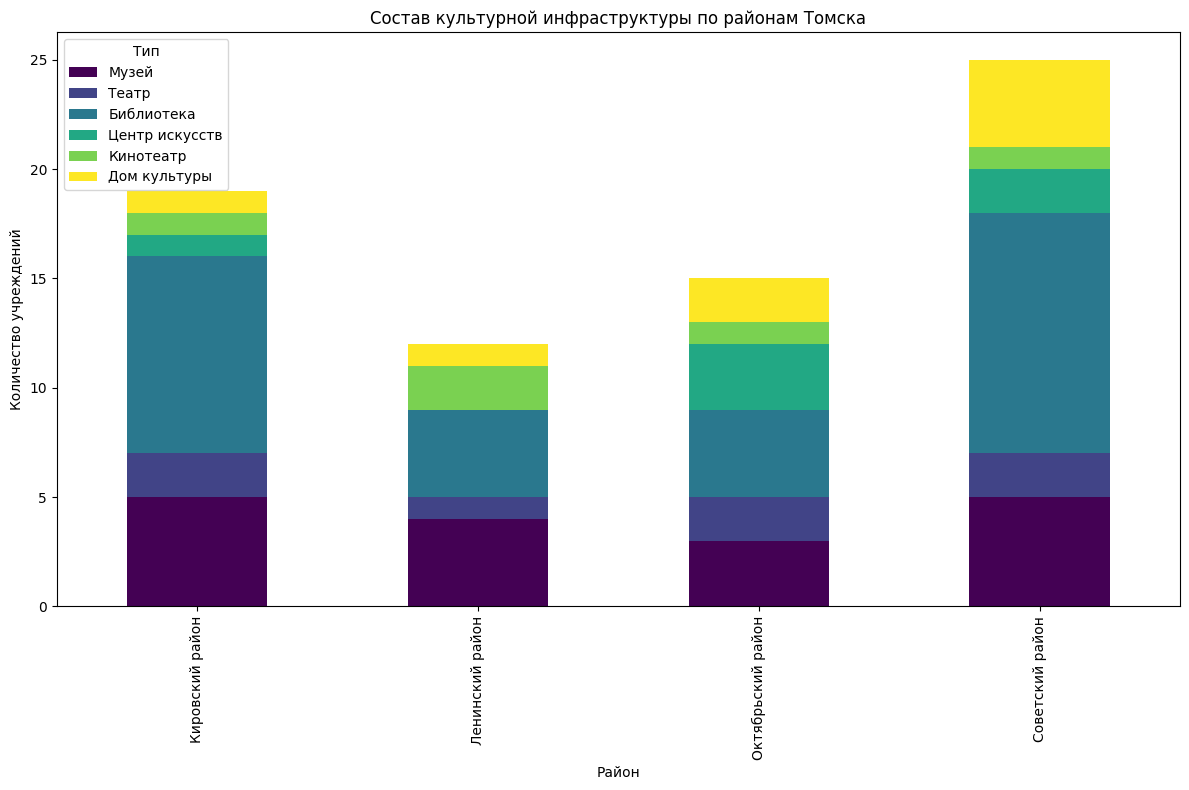

In [16]:
# столбчатая диаграмму по типам для каждого района
types_to_plot = ['Музей', 'Театр', 'Библиотека', 'Центр искусств', 'Кинотеатр', 'Дом культуры']
data_for_plot = districts_with_types[['name'] + types_to_plot].set_index('name')
fig, ax = plt.subplots(figsize=(12, 8))
data_for_plot.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_title('Состав культурной инфраструктуры по районам Томска')
ax.set_xlabel('Район')
ax.set_ylabel('Количество учреждений')
ax.legend(title='Тип')
plt.tight_layout()
plt.savefig('../output/culture_types_by_district.png', dpi=300)
plt.show()

## 11. Выявление дефицита и анализ спектра услуг

### 11.1. Какие культурные потребности закрываются?
- **Библиотеки** – широко представлены во всех районах (наибольшее количество). Обеспечивают информационные и образовательные потребности.
- **Музеи** – сосредоточены в основном в центре (Кировский и Советский районы), что логично для исторической части города.
- **Театры** – также преимущественно в центре.
- **Кинотеатры** – немногочисленны, в основном в центральных районах.
- **Дома культуры** – присутствуют в спальных районах (Ленинский, Октябрьский), что закрывает потребности в кружковой работе и досуге.
- **Центры искусств** – единичны, в основном в центре.

### 11.2. Чего не хватает? («слепые зоны»)
1. **Недостаток учреждений в отдалённых микрорайонах**. Например, в районе Южных и Северных микрорайонов (территориально относящихся к Ленинскому и Октябрьскому районам) фактически отсутствуют объекты культуры (см. карту точек).
2. **Отсутствие концертных залов и выставочных пространств** в данных OSM (не отмечены как специализированные объекты). Возможно, они существуют, но не имеют тега `amenity=arts_centre` или `tourism=museum`. Требуется дополнительное исследование.
3. **Почти полное отсутствие творческих студий, музыкальных школ, школ искусств** в выборке (не все из них отмечены в OSM). Это важная часть дополнительного образования, которая не учтена.
4. **Кинотеатры** – их очень мало, особенно за пределами центра. Жители спальных районов вынуждены ездить в центр для просмотра фильмов.
5. **Культурные центры национальных обществ** – в выборке не представлены, хотя в Томске они есть (например, армянский, татарский культурные центры). Они не имеют соответствующего тега в OSM.

### 11.3. Рекомендации
- **Расширение точек культурного притяжения в микрорайонах**: создание филиалов библиотек, малых концертных площадок в жилых комплексах.
- **Стимулирование маркировки существующих учреждений** в OpenStreetMap (в том числе школ искусств, творческих студий, частных галерей).
- **Развитие мобильных культурных проектов** (передвижные выставки, лектории) для охвата удалённых районов.
- **Создание интерактивной карты культурных ресурсов** с участием жителей для выявления реальных точек притяжения, не отражённых в OSM.

## 12. Итоговые выводы по результатам анализа

- **Всего в Томске в OpenStreetMap отмечено 71 учреждение культуры**.  
  Из них наибольшее количество составляют **библиотеки**, наименьшее – **центры искусств**.
- **Районное распределение неравномерно**:
  - **Советский район** – лидер по общему числу учреждений (25 объектов). Это объясняется большой площадью района и наличием множества библиотек и домов культуры в жилых микрорайонах.
  - **Октябрьский и Ленинский районы** – около 16–17 учреждений каждый, представлены в основном библиотеками и домами культуры.
  - **Кировский район (исторический центр)** – наименьшее общее количество (13 объектов), однако именно здесь сосредоточено максимальное разнообразие типов: музеи, театры, кинотеатры, центры искусств.
- **Качественный состав учреждений**:
  - **Библиотеки** доминируют во всех районах, обеспечивая базовую информационную и образовательную функцию.
  - **Дома культуры** также широко представлены, особенно в спальных районах, закрывая потребности в кружковой работе и досуге.
  - **Музеи и театры** сконцентрированы в историческом центре (Кировский район), что создаёт «культурный центр», но оставляет периферию с ограниченным доступом к этим типам услуг.
  - **Кинотеатры и центры искусств** – малочисленны.
- **Выявлены дефицитные зоны и типы**:
  - **Территориальный дефицит**: отдалённые микрорайоны входящие в Ленинский и Октябрьский районы фактически не имеют собственных учреждений культуры (см. точечную карту).
- **Противоречие между количеством и качеством**: хотя Советский район лидирует по количеству учреждений, спектр услуг в нём менее разнообразен, чем в Кировском районе. Это указывает на необходимость не просто увеличения числа объектов, но и расширения их функционального наполнения.

### Рекомендации для развития культурной инфраструктуры Томска
1. **Создание культурных точек в «белых пятнах»** – организация малых библиотек, творческих пространств в спальных микрорайонах.
2. **Диверсификация услуг в существующих учреждениях** – например, использование помещений домов культуры для выставочных залов, лекториев.
3. **Стимулирование маркировки в OpenStreetMap** – многие реально существующие объекты (школы искусств, частные галереи, музыкальные школы) не отмечены, что искажает картину.
4. **Создание интерактивной карты культурных ресурсов** с участием жителей для выявления реальных потребностей и существующих, но не отмеченных в OSM точек.

Проект демонстрирует, что на основе открытых данных можно выявить как количественные диспропорции, так и качественные лакуны в культурном предложении города. Дальнейший анализ может быть дополнен опросом жителей и интеграцией данных из ведомственных реестров.

In [17]:
print("\n=== итоговая статистика ===")
print(f"Всего учреждений культуры: {len(culture)}")
print(f"Среднее количество на район: {districts_with_culture['culture_count'].mean():.1f}")
print("\nРайон с наибольшим количеством учреждений культуры:")
print(districts_with_culture[['name', 'culture_count']].sort_values('culture_count', ascending=False).head(1))


=== итоговая статистика ===
Всего учреждений культуры: 71
Среднее количество на район: 17.8

Район с наибольшим количеством учреждений культуры:
              name  culture_count
3  Советский район             25
